In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [ ]:
# load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
# scale features
# Initialize scaler
scaler = StandardScaler()
# fit tranform
X_scaled = scaler.fit_transform(X)


In [ ]:
# preview scaled data
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

# DBSCAN Clustering

In [ ]:
# initialize your model
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [ ]:
# fit and predict
labels = dbscan.fit_predict(X_scaled)

In [ ]:
# Creating a cluster column
df['Cluster'] = labels

In [ ]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
199,200,Male,30,137,83,-1
29,30,Female,23,29,87,0
6,7,Female,35,18,6,0
173,174,Male,36,87,92,1
145,146,Male,28,77,97,1
133,134,Female,31,72,71,1
188,189,Female,41,103,17,0
166,167,Male,42,86,20,0
160,161,Female,56,79,35,0
80,81,Male,57,54,51,0


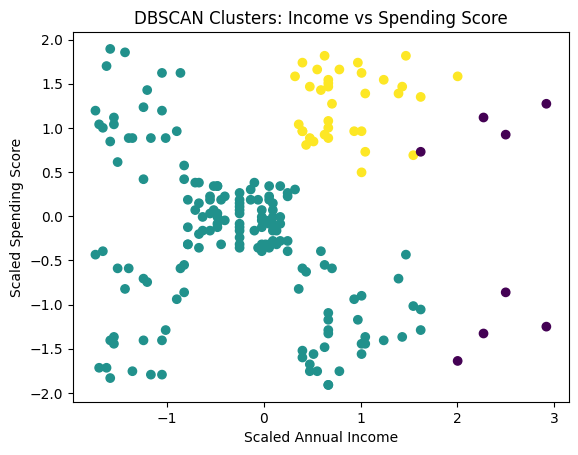

In [ ]:
# cluster visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.title("DBSCAN Clusters: Income vs Spending Score")
plt.xlabel("Scaled Annual Income")
plt.ylabel("Scaled Spending Score")
plt.show()

The Green Mass Cluster(0): There's merging of four distinct customer  segments the (low income/low spend, low income/high spend, average/average and high income/low spend).

The Yellow Group Cluster(1): This are the high income/high spend demographic.

The Purple Points(Noise /-1) : This are outliers because they do not have enough neighbors within the specified radius to form a cluster.

